In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import pickle
from scipy.stats import poisson


In [ ]:
# Load player data
df_players = pd.read_csv('players_22.csv', low_memory=False)

In [ ]:
# Select relevant columns
df_players = df_players[['short_name', 'age', 'nationality_name', 'overall', 'potential',
                         'club_name', 'value_eur', 'wage_eur', 'player_positions']]


In [ ]:
# Select only one position
df_players['player_positions'] = df_players['player_positions'].str.split(',', expand=True)[0]
df_players.dropna(inplace=True)

In [ ]:
# List of players missing the World Cup due to injuries
players_missing_worldcup = ['K. Benzema', 'S. Mané', 'S. Agüero', 'Sergio Ramos',
                             'P. Pogba', 'M. Reus', 'Diogo Jota', 'A. Harit',
                             'N. Kanté', 'G. Lo Celso', 'Piqué']


In [ ]:
# Drop injured players
df_players = df_players[~df_players['short_name'].isin(players_missing_worldcup)]

In [ ]:
# Filter for teams participating in the World Cup
teams_worldcup = [
    'Qatar', 'Brazil', 'Belgium', 'France', 'Argentina', 'England',
    'Spain', 'Portugal', 'Mexico', 'Netherlands', 'Denmark', 'Germany',
    'Uruguay', 'Switzerland', 'United States', 'Croatia', 'Senegal',
    'Iran', 'Japan', 'Morocco', 'Serbia', 'Poland', 'South Korea',
    'Tunisia', 'Cameroon', 'Canada', 'Ecuador', 'Saudi Arabia',
    'Ghana', 'Wales', 'Costa Rica', 'Australia'
]
df_players = df_players[df_players['nationality_name'].isin(teams_worldcup)]

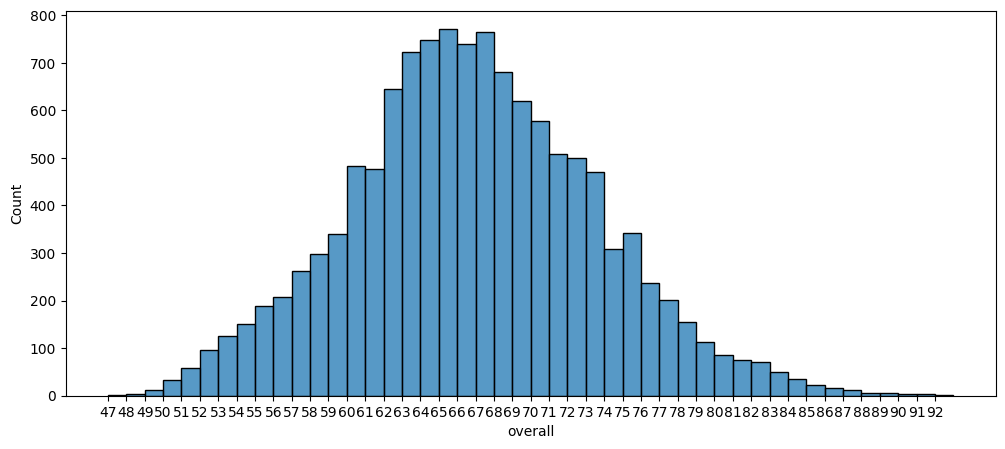

In [ ]:
# Plot histogram of player overall ratings
plt.figure(figsize=(12, 5))
sns.histplot(df_players, x='overall', binwidth=1)
plt.xticks(np.arange(df_players['overall'].min(), df_players['overall'].max(), 1))
plt.show()

In [ ]:
# Drop duplicates by player position
df_best_players = df_players.drop_duplicates('player_positions').reset_index(drop=True)

In [ ]:
# Extract country short names for national players
country_short = df_best_players['nationality_name'].str.extract('(^\w{3})', expand=False).str.upper()
df_best_players['name_nationality'] = df_best_players['short_name'] + ' (' + country_short + ')'


<ipython-input-14-9463e8e6cf71>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_best_players, x='overall', y='name_nationality', palette=sns.color_palette('pastel'))
<ipython-input-14-9463e8e6cf71>:3: UserWarning: 
The palette list has fewer values (10) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_best_players, x='overall', y='name_nationality', palette=sns.color_palette('pastel'))


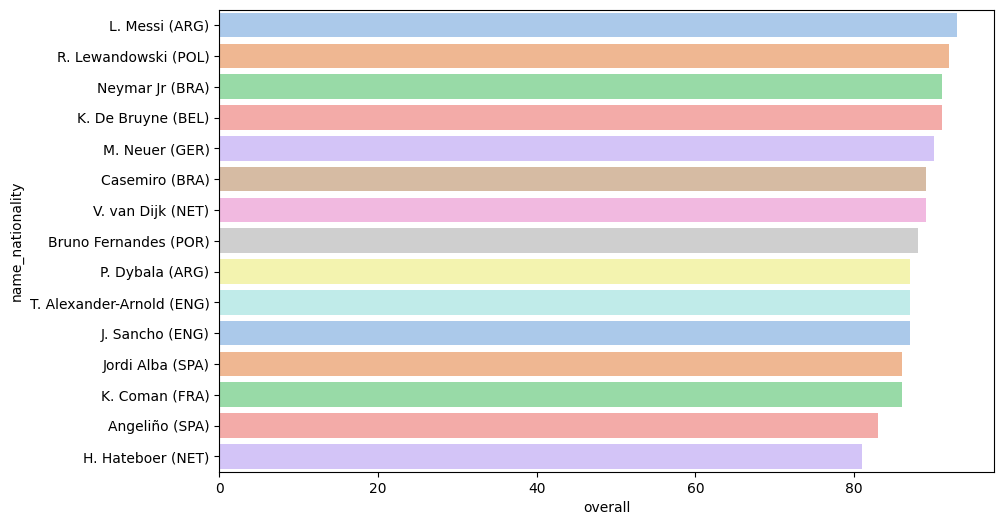

In [ ]:
# Plot best players by nationality
plt.figure(figsize=(10, 6))
sns.barplot(data=df_best_players, x='overall', y='name_nationality', palette=sns.color_palette('pastel'))
plt.show()

In [ ]:
# Function to get the best squad for a nationality
def best_squad(nationality):
    df_best_squad = df_players.copy()
    df_best_squad = df_best_squad.groupby(['nationality_name', 'player_positions']).head(2)
    df_best_squad = df_best_squad[df_best_squad['nationality_name'] == nationality].sort_values(
        ['player_positions', 'overall', 'potential'], ascending=False)
    return df_best_squad


In [ ]:
# Example: Get best squad for Brazil
print(best_squad('France'))

average_overall = [best_squad(team)['overall'].mean() for team in teams_worldcup]

df_average_overall = pd.DataFrame({'Teams': teams_worldcup, 'AVG_Overall': average_overall})
df_average_overall = df_average_overall.dropna()
df_average_overall = df_average_overall.sort_values('AVG_Overall', ascending=False)
df_average_overall




         short_name  age nationality_name  overall  potential  \
6         K. Mbappé   22           France       91         95   
83     A. Griezmann   30           France       85         85   
361      N. Mukiele   23           France       81         85   
1035    F. Centonze   25           France       77         80   
192      O. Dembélé   24           France       83         88   
435      F. Thauvin   28           France       80         80   
639        J. Ikoné   23           France       79         83   
1654     P. Capelle   34           France       75         75   
621       B. Pavard   25           France       79         82   
610      R. Aguilar   28           France       79         79   
1230     T. Delaine   29           France       76         76   
3018   R. Aït Nouri   20           France       73         84   
382        M. Diaby   21           France       81         88   
398        D. Payet   34           France       80         80   
64         K. Coman   25 

,Teams,AVG_Overall
6,Spain,82.400000
7,Portugal,81.733333
5,England,81.700000
1,Brazil,81.666667
3,France,81.000000
4,Argentina,80.566667
11,Germany,80.433333
2,Belgium,79.034483
9,Netherlands,78.758621
8,Mexico,77.727273


from matplotlib import pyplot as plt
df_average_overall['AVG_Overall'].plot(kind='hist', bins=20, title='AVG_Overall')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df_average_overall['AVG_Overall'].plot(kind='line', figsize=(8, 4), title='AVG_Overall')
plt.gca().spines[['top', 'right']].set_visible(False)

<ipython-input-17-1a8cf3c1a52a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_average_overall[:10], x='Teams', y='AVG_Overall',


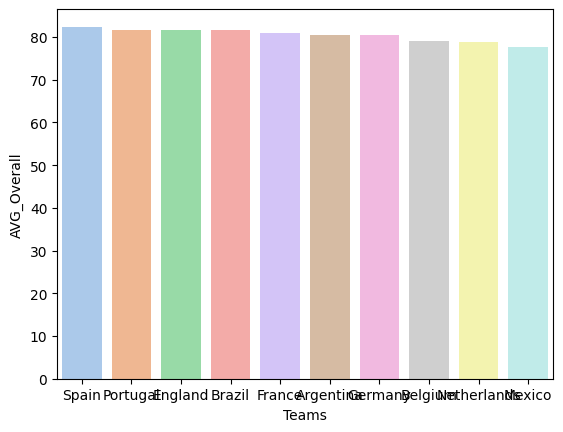

Spain 4-2-3-1 85.1
Portugal 4-2-3-1 84.9
England 4-4-2 84.45454545454545
Brazil 4-3-3 84.81818181818181
France 4-2-3-1 83.9
Argentina 4-3-3 83.54545454545455
Germany 4-2-3-1 84.1
Belgium 4-3-3 82.54545454545455
Netherlands 4-4-2 82.54545454545455


In [ ]:
# Ensure you pass the DataFrame as the 'data' argument
sns.barplot(data=df_average_overall[:10], x='Teams', y='AVG_Overall',
            palette=sns.color_palette('pastel'))
plt.show()


def best_lineup(nationality, lineup):
    lineup_count = [lineup.count(i) for i in lineup]

    df_lineup = pd.DataFrame({'position': lineup, 'count': lineup_count})
    positions_non_repeated = df_lineup[df_lineup['count'] <= 1]['position'].values
    positions_repeated = df_lineup[df_lineup['count'] > 1]['position'].values

    df_squad = best_squad(nationality)

    df_lineup = pd.concat([
        df_squad[df_squad['player_positions'].isin(positions_non_repeated)].drop_duplicates('player_positions', keep='first'),
        df_squad[df_squad['player_positions'].isin(positions_repeated)]]
    )
    return df_lineup[['short_name', 'overall', 'club_name', 'player_positions']]
dict_formation = {
    '4-3-3': ['GK', 'RB', 'CB', 'CB', 'LB', 'CDM', 'CM', 'CAM', 'RW', 'ST', 'LW'],
    '4-4-2': ['GK', 'RB', 'CB', 'CB', 'LB', 'RM', 'CM', 'CM', 'LM', 'ST', 'ST'],
    '4-2-3-1': ['GK', 'RB', 'CB', 'CB', 'LB', 'CDM', 'CDM', 'CAM', 'CAM', 'CAM', 'ST'],
}
for index, row in df_average_overall[:9].iterrows():
    max_average = None
    for key, values in dict_formation.items():
        average = best_lineup(row['Teams'], values)['overall'].mean()
        if max_average is None or average>max_average:
           max_average = average
           formation = key
    print(row['Teams'], formation, max_average)

In [ ]:
# best_lineup('Spain', dict_formation['4-2-3-1'])
# best_lineup('Argentina', dict_formation['4-3-3'])
best_lineup('Brazil', dict_formation['4-3-3'])
dict_table = pickle.load(open('dict_table','rb'))
df_historical_data = pd.read_csv('clean_fifa_worldcup_matches.csv')
df_fixture = pd.read_csv('clean_fifa_worldcup_fixture.csv')
df_home = df_historical_data[['HomeTeam', 'HomeGoals', 'AwayGoals']]
df_away = df_historical_data[['AwayTeam', 'HomeGoals', 'AwayGoals']]

df_home = df_home.rename(columns={'HomeTeam':'Team', 'HomeGoals': 'GoalsScored', 'AwayGoals': 'GoalsConceded'})
df_away = df_away.rename(columns={'AwayTeam':'Team', 'HomeGoals': 'GoalsConceded', 'AwayGoals': 'GoalsScored'})

df_team_strength = pd.concat([df_home, df_away], ignore_index=True).groupby(['Team']).mean()
df_team_strength

,GoalsScored,GoalsConceded
Team,,
Algeria,1.000000,1.461538
Angola,0.333333,0.666667
Argentina,1.691358,1.148148
Australia,0.812500,1.937500
Austria,1.482759,1.620690
...,...,...
Uruguay,1.553571,1.321429
Wales,0.800000,0.800000
West Germany,2.112903,1.241935


In [ ]:
def predict_points(home, away):
    if home in df_team_strength.index and away in df_team_strength.index:
        # goals_scored * goals_conceded
        lamb_home = df_team_strength.at[home,'GoalsScored'] * df_team_strength.at[away,'GoalsConceded']
        lamb_away = df_team_strength.at[away,'GoalsScored'] * df_team_strength.at[home,'GoalsConceded']
        prob_home, prob_away, prob_draw = 0, 0, 0
        for x in range(0,11): #number of goals home team
            for y in range(0, 11): #number of goals away team
                p = poisson.pmf(x, lamb_home) * poisson.pmf(y, lamb_away)
                if x == y:
                    prob_draw += p
                elif x > y:
                    prob_home += p
                else:
                    prob_away += p

        points_home = 3 * prob_home + prob_draw
        points_away = 3 * prob_away + prob_draw
        return (points_home, points_away)
    else:
        return (0, 0)
    print(predict_points('England', 'United States'))
print(predict_points('Argentina', 'Mexico'))
print(predict_points('Qatar (H)', 'Ecuador')) # Qatar vs Team X -> 0 points to both


(2.3129151525530505, 0.5378377125059863)
(0, 0)


In [ ]:
df_fixture_group_48 = df_fixture[:48].copy()
df_fixture_knockout = df_fixture[48:56].copy()
df_fixture_quarter = df_fixture[56:60].copy()
df_fixture_semi = df_fixture[60:62].copy()
df_fixture_final = df_fixture[62:].copy()

for group in dict_table:
    teams_in_group = dict_table[group]['Team'].values
    df_fixture_group_6 = df_fixture_group_48[df_fixture_group_48['home'].isin(teams_in_group)]
    for index, row in df_fixture_group_6.iterrows():
        home, away = row['home'], row['away']
        points_home, points_away = predict_points(home, away)
        dict_table[group].loc[dict_table[group]['Team'] == home, 'Pts'] += points_home
        dict_table[group].loc[dict_table[group]['Team'] == away, 'Pts'] += points_away

    dict_table[group] = dict_table[group].sort_values('Pts', ascending=False).reset_index()
    dict_table[group] = dict_table[group][['Team', 'Pts']]
    dict_table[group] = dict_table[group].round(0)
    dict_table['Group A']
    df_fixture_knockout
    for group in dict_table:
        group_winner = dict_table[group].loc[0, 'Team']
        runners_up = dict_table[group].loc[1, 'Team']
        df_fixture_knockout.replace({f'Winners {group}':group_winner,
                                 f'Runners-up {group}':runners_up}, inplace=True)


df_fixture_knockout['winner'] = '?'
df_fixture_knockout
def get_winner(df_fixture_updated):
    for index, row in df_fixture_updated.iterrows():
        home, away = row['home'], row['away']
        points_home, points_away = predict_points(home, away)
        if points_home > points_away:
            winner = home
        else:
            winner = away
        df_fixture_updated.loc[index, 'winner'] = winner
    return df_fixture_updated
get_winner(df_fixture_knockout)

def update_table(df_fixture_round_1, df_fixture_round_2):
    for index, row in df_fixture_round_1.iterrows():
        winner = df_fixture_round_1.loc[index, 'winner']
        match = df_fixture_round_1.loc[index, 'score']
        df_fixture_round_2.replace({f'Winners {match}':winner}, inplace=True)
    df_fixture_round_2['winner'] = '?'
    return df_fixture_round_2
update_table(df_fixture_knockout, df_fixture_quarter)


get_winner(df_fixture_quarter)

get_winner(df_fixture_quarter)
update_table(df_fixture_quarter, df_fixture_semi)

get_winner(df_fixture_semi)

update_table(df_fixture_semi, df_fixture_final)

get_winner(df_fixture_final)

,home,score,away,year,winner
62,Losers Match 61,Match 63,Losers Match 62,2022,Losers Match 62
63,Brazil,Match 64,France,2022,Brazil
